In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
!which python

/Users/personal/Documents/授業/M2/DSS実習/venv/bin/python


        date           S     alpha
0 2026-01-01  100.000000  0.300000
1 2026-01-02  100.059684  0.297850
2 2026-01-05  100.361642  0.295843
3 2026-01-06  100.110248  0.301792
4 2026-01-07  100.733438  0.305551
          date          S     alpha
248 2026-12-15  78.500357  0.649075
249 2026-12-16  78.315220  0.665875
250 2026-12-17  77.126769  0.687551
251 2026-12-18  78.299535  0.684433
252 2026-12-21  76.757159  0.684169


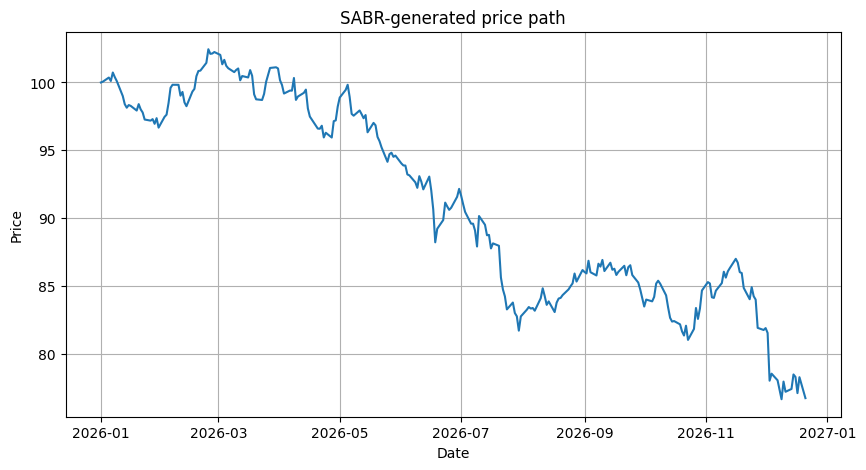

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def generate_sabr_path(
    s0: float = 100.0,
    alpha0: float = 0.2,
    beta: float = 0.7,
    rho: float = -0.3,
    nu: float = 0.5,
    n_days: int = 252,
    seed: int | None = 42,
) -> pd.DataFrame:
    """
    Generate one SABR price path.

    SABR model:
        dS_t = alpha_t * S_t^beta dW_t
        d alpha_t = nu * alpha_t dZ_t
        corr(dW_t, dZ_t) = rho dt
    """

    rng = np.random.default_rng(seed)

    dt = 1.0 / 252.0

    s = np.zeros(n_days + 1)
    alpha = np.zeros(n_days + 1)

    s[0] = s0
    alpha[0] = alpha0

    for t in range(n_days):
        z1 = rng.normal()
        z2 = rng.normal()

        dW = np.sqrt(dt) * z1
        dZ = np.sqrt(dt) * (rho * z1 + np.sqrt(1.0 - rho**2) * z2)

        # Volatility process
        alpha[t + 1] = alpha[t] * np.exp(
            -0.5 * nu**2 * dt + nu * dZ
        )

        # Asset process
        s_next = s[t] + alpha[t] * max(s[t], 0.0) ** beta * dW

        # Prevent negative prices caused by Euler discretization
        s[t + 1] = max(s_next, 0.0)

    dates = pd.bdate_range(start="2026-01-01", periods=n_days + 1)

    return pd.DataFrame(
        {
            "date": dates,
            "S": s,
            "alpha": alpha,
        }
    )


df = generate_sabr_path(
    s0=100.0,
    alpha0=0.3,
    beta=0.7,
    rho=-0.4,
    nu=0.6,
    n_days=252,
    seed=0,
)

print(df.head())
print(df.tail())

plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["S"])
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("SABR-generated price path")
plt.grid(True)
plt.show()

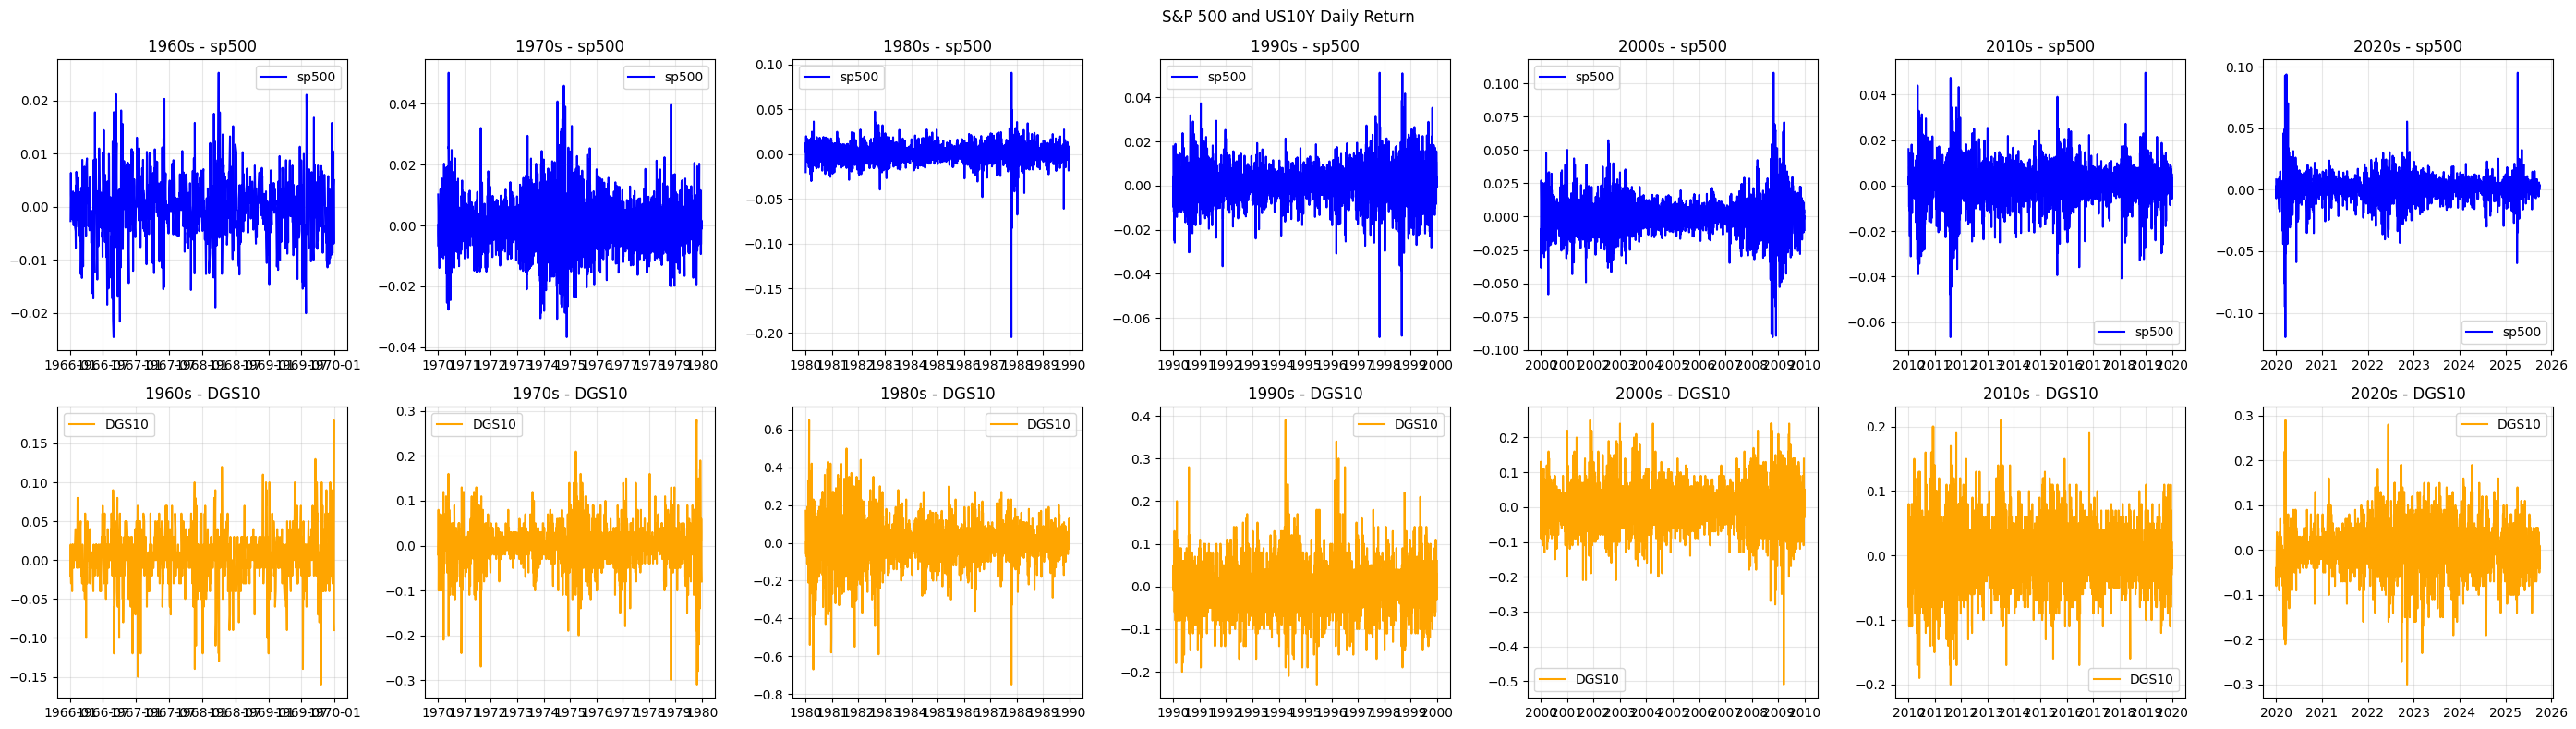

In [15]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_csv(
    file_path: str,
    x_col: str | None = None,
    y_cols: list[str] | None = None,
    title: str = "CSV Data Plot",
    figsize: tuple[int, int] = (12, 5),
    split_by_decade: bool = False,
) -> pd.DataFrame:
    """CSVを読み込み、指定列をグラフ描画してDataFrameを返す。
    
    split_by_decade=True かつ y_cols が2列の場合、10年ごとの複数サブプロットで、
    上に y_cols[0]、下に y_cols[1] を配置して描画する。
    """
    df = pd.read_csv(file_path)

    # 先頭列が日付文字列ならx軸として扱う
    if x_col is None:
        first_col = df.columns[0]
        parsed = pd.to_datetime(df[first_col], errors="coerce")
        if parsed.notna().mean() > 0.8:
            df[first_col] = parsed
            x_col = first_col

    # 描画対象列の自動選択
    if y_cols is None:
        exclude = {x_col} if x_col is not None else set()
        y_cols = [c for c in df.columns if c not in exclude]

    # 10年ごとに分割して描画
    if split_by_decade and x_col is not None and len(y_cols) == 2:
        df['decade'] = df[x_col].dt.year // 10 * 10
        decades = sorted(df['decade'].unique())
        n_decades = len(decades)
        
        fig, axes = plt.subplots(2, n_decades, figsize=(4*n_decades, 8))
        if n_decades == 1:
            axes = axes.reshape(2, 1)
        
        for i, decade in enumerate(decades):
            mask = df['decade'] == decade
            decade_data = df[mask]
            
            # 上：y_cols[0] (sp500)
            axes[0, i].plot(decade_data[x_col], decade_data[y_cols[0]], label=y_cols[0], color='blue')
            axes[0, i].set_title(f'{decade}s - {y_cols[0]}')
            axes[0, i].grid(True, alpha=0.3)
            axes[0, i].legend()
            
            # 下：y_cols[1] (DGS10)
            axes[1, i].plot(decade_data[x_col], decade_data[y_cols[1]], label=y_cols[1], color='orange')
            axes[1, i].set_title(f'{decade}s - {y_cols[1]}')
            axes[1, i].grid(True, alpha=0.3)
            axes[1, i].legend()
            
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()
    else:
        # 通常の描画
        plt.figure(figsize=figsize)
        for col in y_cols:
            if x_col is None:
                plt.plot(df[col], label=col)
            else:
                plt.plot(df[x_col], df[col], label=col)

        plt.title(title)
        plt.xlabel(x_col if x_col is not None else "index")
        plt.ylabel("value")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return df


_ = plot_csv(
    "train_sp500_us10y.csv",
    y_cols=["sp500", "DGS10"],
    title="S&P 500 and US10Y Daily Return",
    split_by_decade=True,
)

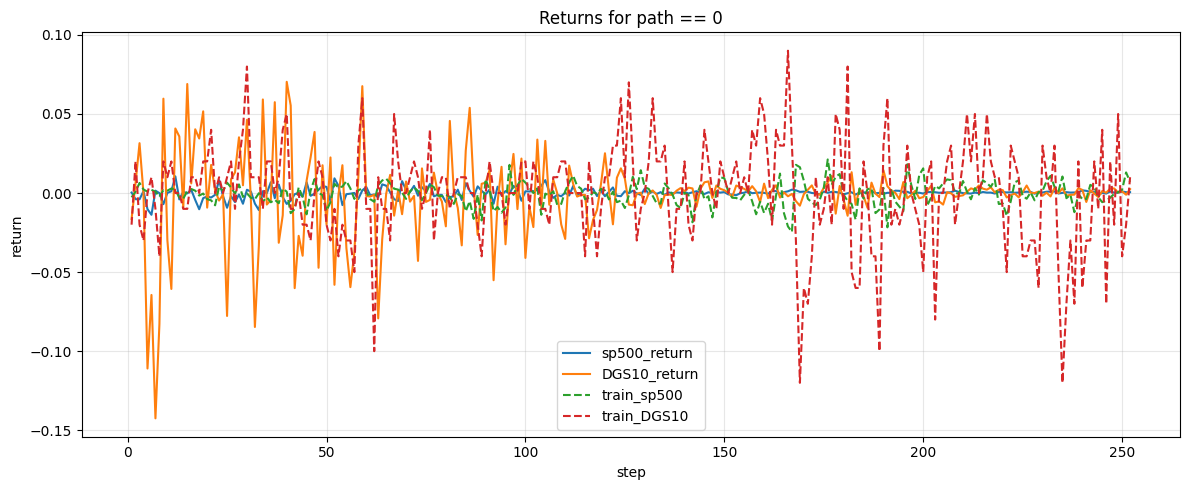

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_returns_by_path(
    file_path: str,
    path_value: int,
    columns: tuple[str, str] = ("sp500_return", "DGS10_return"),
    train_file_path: str | None = "train_sp500_us10y.csv",
    train_columns: tuple[str, str] = ("sp500", "DGS10"),
    figsize: tuple[int, int] = (12, 5),
) -> pd.DataFrame:
    """
    generated_sabr_series.csvの指定pathを描画し、必要なら
    train_sp500_us10y.csvの同ステップ数データを重ねて描画する。
    """
    df = pd.read_csv(file_path)

    required = {"path", *columns}
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in generated file: {missing}")

    filtered = df[df["path"] == path_value].copy()
    if filtered.empty:
        raise ValueError(f"No rows found for path == {path_value}")

    x = filtered["step"] if "step" in filtered.columns else filtered.index

    plt.figure(figsize=figsize)
    for col in columns:
        plt.plot(x, filtered[col], label=col)

    if train_file_path is not None:
        train_df = pd.read_csv(train_file_path)

        train_missing = [c for c in train_columns if c not in train_df.columns]
        if train_missing:
            raise ValueError(f"Missing required columns in train file: {train_missing}")

        n = len(filtered)
        if len(train_df) < n:
            raise ValueError(
                f"train file has only {len(train_df)} rows, but {n} steps are required"
            )

        train_part = train_df.iloc[:n].reset_index(drop=True)
        plt.plot(x, train_part[train_columns[0]], "--", label=f"train_{train_columns[0]}")
        plt.plot(x, train_part[train_columns[1]], "--", label=f"train_{train_columns[1]}")

    plt.title(f"Returns for path == {path_value}")
    plt.xlabel("step" if "step" in filtered.columns else "index")
    plt.ylabel("return")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return filtered


_ = plot_returns_by_path(
    "generated_sabr_series.csv",
    path_value=0,
    columns=("sp500_return", "DGS10_return"),
    train_file_path="train_sp500_us10y.csv",
    train_columns=("sp500", "DGS10"),
)

In [18]:
df = pd.read_csv("train_sp500_us10y.csv")

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14734 entries, 0 to 14733
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  14734 non-null  str    
 1   sp500       14734 non-null  float64
 2   DGS10       14734 non-null  float64
dtypes: float64(2), str(1)
memory usage: 345.5 KB


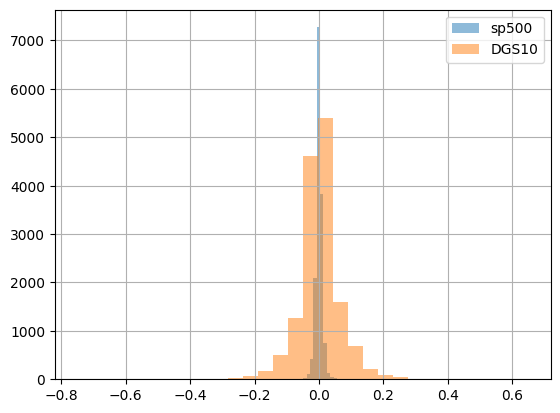

In [25]:
ax = plt.gca()
df["sp500"].hist(ax=ax, bins=30, alpha=0.5, label="sp500")
df["DGS10"].hist(ax=ax, bins=30, alpha=0.5, label="DGS10")
ax.legend()
plt.show()

In [27]:
df_gen = pd.read_csv("generated_sabr_series.csv")


In [28]:
df_gen.info()

<class 'pandas.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   path          2520 non-null   int64  
 1   step          2520 non-null   int64  
 2   sp500_return  2520 non-null   float64
 3   DGS10_return  2520 non-null   float64
 4   sp500_price   2520 non-null   float64
 5   DGS10_price   2520 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 118.3 KB


In [ ]:
df_gen = df_gen[df_gen['path'] == 0]

,path,step,sp500_return,DGS10_return,sp500_price,DGS10_price
0,0,1,0.000326,-0.016358,100.032561,98.364166
1,0,2,-0.003891,0.006372,99.643324,98.990943
2,0,3,-0.003955,0.031547,99.249236,102.113761
3,0,4,0.001193,-0.000404,99.367646,102.072507
4,0,5,-0.010202,-0.110949,98.353886,90.747652
...,...,...,...,...,...,...
247,0,248,0.000257,0.002933,100.235274,62.444603
248,0,249,0.000159,0.000305,100.251243,62.463624
249,0,250,0.000961,0.001096,100.347608,62.532077
250,0,251,0.000533,-0.001068,100.401060,62.465303
